# kaggle 房价预测

[kaggle比赛地址](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview)

## 读取数据集

In [60]:
import hashlib
import os
import tarfile
import zipfile
import requests

#@save 数据集地址
DATA_HUB = dict()
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'

In [61]:
# 数据集下载
def download(name, cache_dir=os.path.join('..', 'data')):  #@save
    """下载一个DATA_HUB中的文件，返回本地文件名"""
    assert name in DATA_HUB, f"{name} 不存在于 {DATA_HUB}"
    url, sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname  # 命中缓存
    print(f'正在从{url}下载{fname}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

In [62]:
# 数据集解压
def download_extract(name, folder=None):  #@save
    """下载并解压zip/tar文件"""
    fname = download(name)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, '只有zip/tar文件可以被解压缩'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def download_all():  #@save
    """下载DATA_HUB中的所有文件"""
    for name in DATA_HUB:
        download(name)

In [63]:
# 如果没有安装pandas，请取消下一行的注释
# !pip install pandas

%matplotlib inline
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

In [64]:
DATA_HUB['kaggle_house_train'] = (DATA_URL + 'kaggle_house_pred_train.csv', '585e9cc93e70b39160e7921475f9bcd7d31219ce')  # 下载训练集
DATA_HUB['kaggle_house_test'] = (DATA_URL + 'kaggle_house_pred_test.csv', 'fa19780a7b011d9b009e8bff8e99922a8ee2eb90')    # 下载测试集

train_data = pd.read_csv(download('kaggle_house_train'))
test_data = pd.read_csv(download('kaggle_house_test'))

print(train_data.shape)
print(test_data.shape)

(1460, 81)
(1459, 80)


In [65]:
print(train_data.iloc[0:4, [0,1,2,3,-3,-2,-1] ])

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


In [66]:
# 数据预处理，去掉第一列Id，不包含特征信息，对训练无用
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))
print(all_features.shape)

(2919, 79)


## 数据预处理

首先，**将所有缺失的值替换为相应特征的平均值。**  
然后，**通过将特征重新缩放到零均值和单位方差来标准化数据**：

$$x \leftarrow \frac{x - \mu}{\sigma}$$

其中 $\mu$ 和 $\sigma$ 分别表示均值和标准差。缩放之后，这些特征具有零均值和单位方差。

$$
E\left[\frac{X-\mu}{\sigma}\right] 
= E\left[\frac{1}{\sigma}X - \frac{\mu}{\sigma}\right]
= \frac{1}{\sigma}E[X] - \frac{\mu}{\sigma}
= 0
$$

$$E[(x-\mu)^2] = (\sigma^2 + \mu^2) - 2\mu^2+\mu^2 = \sigma^2$$

In [75]:
# 若无法获得测试数据，则可根据训练数据计算均值和标准差
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index # 找出所有列为数值型的列名
all_features[numeric_features] = all_features[numeric_features].apply(lambda x: (x - x.mean()) / (x.std()))

# 在标准化数据之后，变成了0均值，因此我们可以将缺失值设置为0
all_features[numeric_features] = all_features[numeric_features].fillna(0)

接下来，我们 **处理离散值，我们用独热编码替换它们**  
例如，“MSZoning” 包含值 “RL” 和 “Rm”，我们将创建两个新的指示器特征 “MSZoning_RL” 和 “MSZoning_RM”，其值为 0 或 1。  
根据独热编码，如果“MSZoning”的原始值为“RL”，则：“MSZoning_RL”为1，“MSZoning_RM”为0，`pandas` 软件包会自动为我们实现这一点。  


In [76]:
# “Dummy_na=True” 将 “na”（缺失值）视为有效的特征值，并为其创建指示符特征
all_features = pd.get_dummies(all_features, dummy_na=True, dtype='int8')
print(all_features.shape)
all_features.to_csv("../data/all_features.csv", index=False)

(2919, 330)


经过转换后特征的总数量从79个增加到331个，通过`values`属性，我们可以 **从`pandas`格式中提取NumPy格式，并将其转换为张量表示** 用于训练。


In [77]:
n_train = train_data.shape[0] # 训练数据行数
train_features = torch.tensor(all_features[:n_train].values, dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:].values, dtype=torch.float32)
# 将 SalePrice 列转成列向量
train_labels = torch.tensor(train_data.SalePrice.values.reshape(-1, 1), dtype=torch.float32)

## 训练
首先，训练一个带有损失平方的线性模型。 显然线性模型很难在竞赛中获胜，但线性模型提供了一种健全性检查， 以查看数据中是否存在有意义的信息。   
如果我们在这里不能做得比随机猜测更好，那么我们很可能存在数据处理错误。   
如果一切顺利，线性模型将作为基线（baseline）模型， 让我们直观地知道最好的模型有超出简单的模型多少。

In [70]:
loss = nn.MSELoss() # 均方误差损失函数
in_features = train_features.shape[1] # 特征数

def get_net():
    net = nn.Sequential(nn.Linear(in_features,1)) # 输入特征维度，输出特征维度
    return net

我们更关心相对误差 $$\frac{y - \hat{y}}{y}$$
而不是绝对误差 $$y - \hat{y}$$
例如，在农村地区估计一栋房子的价格时，假设我们的预测偏差了10万美元，然而那里一栋典型的房子的价值是12.5万美元，那么模型可能做得很糟糕，另一方面，如果我们在加州豪宅区的预测出现同样的10万美元的偏差，房价中位数超过400万美元，这可能是一个不错的预测。  

由于相对误差不好计算，对数误差可以近似相对误差，因此这里使用**对数误差**，事实上，这也是比赛中官方用来评价提交质量的误差指标。

即将 $$\delta \quad for \quad |\log y - \log \hat{y}| \leq \delta$$ 
转换为 $$e^{-\delta} \leq \frac{\hat{y}}{y} \leq e^\delta$$
这使得预测价格的对数与真实标签价格的对数之间出现以下均方根误差（开根号保持量纲一致）：

$$\sqrt{\frac{1}{n}\sum_{i=1}^n\left(\log y_i -\log \hat{y}_i\right)^2}$$

In [80]:
def log_rmse(net, features, labels):
    # 为了在取对数时进一步稳定该值，将小于1的值设置为1
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds), torch.log(labels)))
    return rmse.item()

**我们的训练函数将借助Adam优化器**，Adam优化器的主要吸引力在于它对初始学习率不那么敏感。  

训练神经网络分4步：  

1. 前向传播 $\hat{y} = f(x)$  

2. 计算损失 $loss(y,\hat{y})$  

3. 反向传播 $\frac{\partial loss}{\partial w}$  

4. 优化器更新 $w = w - \eta \cdot gradient$  


   常见优化器对比:  
    - SGD 最基础
    - Momentum 加速SGD
    - RMSProp 自适应学习率
    - **Adam** Momentum + RMSProp


In [82]:
'''
num_epochs 训练轮数
learning_rate 学习率
weight_decay 权重衰减（L2正则）
batch_size 每批数据大小
'''
def train(net, train_features, train_labels, test_features, test_labels,
          num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    # 这里使用的是Adam优化算法（改进版的梯度下降算法）
    optimizer = torch.optim.Adam(net.parameters(),
                                 lr = learning_rate,
                                 weight_decay = weight_decay)
    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad() # 地图清零，pytorch默认会累加梯度
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net, train_features, train_labels)) # 只用于评估，不用于训练
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

## K折交叉验证

我们首先需要定义一个函数，在$K$折交叉验证过程中返回第$i$折的数据，具体地说，它选择第$i$个切片作为验证数据，其余部分作为训练数据。  
（注意：这并不是处理数据的最有效方法，如果我们的数据集大得多，会有其他解决办法。  ）


In [83]:
def get_k_fold_data(k, i, X, y):
    assert k > 1
    fold_size = X.shape[0] // k
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train, X_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
    return X_train, y_train, X_valid, y_valid

当我们在$K$折交叉验证中训练$K$次后，[**返回训练和验证误差的平均值**]。

In [84]:
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay, batch_size):
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate, weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                     xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                     legend=['train', 'valid'], yscale='log')
        print(f'折{i + 1}，训练log rmse{float(train_ls[-1]):f}, 'f'验证log rmse{float(valid_ls[-1]):f}')
    return train_l_sum / k, valid_l_sum / k

## 模型选择

找到一组调优的超参数可能需要时间，这取决于一个人优化了多少变量。
有了足够大的数据集和合理设置的超参数，$K$折交叉验证往往对多次测试具有相当的稳定性。
然而，如果我们尝试了不合理的超参数，我们可能会发现验证效果不再代表真正的误差。

请注意，有时一组超参数的训练误差可能非常低，但$K$折交叉验证的误差要高得多，
这表明模型过拟合了。
在整个训练过程中，我们希望监控训练误差和验证误差这两个数字。
较少的过拟合可能表明现有数据可以支撑一个更强大的模型，
较大的过拟合可能意味着我们可以通过正则化技术来获益。


折1，训练log rmse9.362794, 验证log rmse9.363172
折2，训练log rmse9.289814, 验证log rmse9.450299
折3，训练log rmse9.342031, 验证log rmse9.448342
折4，训练log rmse9.332404, 验证log rmse9.448433
折5，训练log rmse9.337649, 验证log rmse9.450170
5-折验证: 平均训练log rmse: 9.332939, 平均验证log rmse: 9.432083


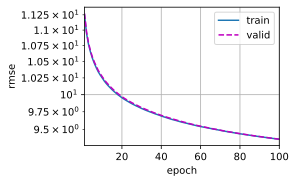

In [115]:
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 0.01, 0.01, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr, weight_decay, batch_size)
print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, 'f'平均验证log rmse: {float(valid_l):f}')

##  [**提交Kaggle预测**]

既然我们知道应该选择什么样的超参数，
我们不妨使用所有数据对其进行训练
（而不是仅使用交叉验证中使用的$1-1/K$的数据）。
然后，我们通过这种方式获得的模型可以应用于测试集。
将预测保存在CSV文件中可以简化将结果上传到Kaggle的过程。

In [117]:
def train_and_pred(train_features, test_features, train_labels, test_data,
                   num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, lr, weight_decay, batch_size)
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
             ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
    print(f'训练log rmse：{float(train_ls[-1]):f}')
    # 将网络应用于测试集。
    preds = net(test_features).detach().numpy()
    # 将其重新格式化以导出到Kaggle
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('../data/submission.csv', index=False)

如果测试集上的预测与$K$倍交叉验证过程中的预测相似，
那就是时候把它们上传到Kaggle了。
下面的代码将生成一个名为`submission.csv`的文件。

训练log rmse：9.278539


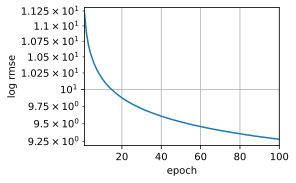

In [118]:
train_and_pred(train_features, test_features, train_labels, test_data, num_epochs, lr, weight_decay, batch_size)

接下来，提交预测到Kaggle上，并查看在测试集上的预测与实际房价（标签）的比较情况。

* 登录Kaggle网站，访问房价预测竞赛页面。
* 点击“Submit Predictions”或“Late Submission”按钮（在撰写本文时，该按钮位于右侧）。
* 点击页面底部虚线框中的“Upload Submission File”按钮，选择要上传的预测文件。
* 点击页面底部的“Make Submission”按钮，即可查看结果。

## 小结

* 真实数据通常混合了不同的数据类型，需要进行预处理。
* 常用的预处理方法：将实值数据重新缩放为零均值和单位方法；用均值替换缺失值。
* 将类别特征转化为指标特征，可以使我们把这个特征当作一个独热向量来对待。
* 我们可以使用$K$折交叉验证来选择模型并调整超参数。
* 对数对于相对误差很有用。

## 练习

1. 把预测提交给Kaggle，它有多好？
1. 能通过直接最小化价格的对数来改进模型吗？如果试图预测价格的对数而不是价格，会发生什么？
1. 用平均值替换缺失值总是好主意吗？提示：能构造一个不随机丢失值的情况吗？
1. 通过$K$折交叉验证调整超参数，从而提高Kaggle的得分。
1. 通过改进模型（例如，层、权重衰减和dropout）来提高分数。
1. 如果我们没有像本节所做的那样标准化连续的数值特征，会发生什么？
